In [41]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
id_list = [925, 165, 9, 477, 291, 162] #InfraRed = 925, concrete = 165, Auto MPG = 9, 
        #Real estate valuation = 477, Air-foil self-noise = 291, forest fires = 162

In [43]:
nr_of_seeds = 30 #nr of seeds in the experiments
index = 162

In [44]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [45]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse']]
    return topk_d, topk_df

In [46]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27956\3948872984.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27956\3948872984.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['exponent'] = 1
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27956\3948872984.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

<Axes: xlabel='exponent', ylabel='rmse'>

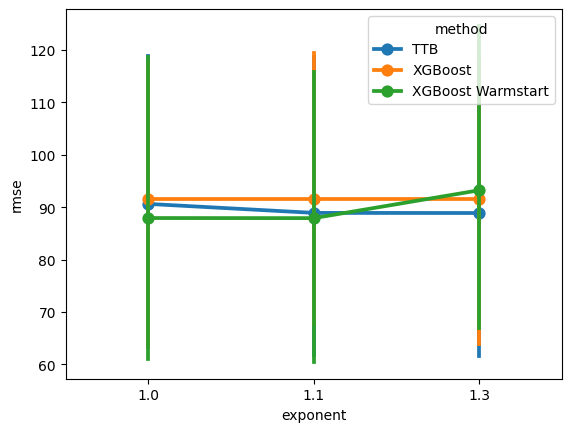

In [47]:
#pointplot
concept_drift_list = [1.1, 1.3]

dat = pd.read_csv(f'results/ttb_LS_{index}.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'
best_LSTransferTreeBoost['exponent'] = 1

data = pd.read_csv(f'results/xgb_{index}.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'
best_XGBoost['exponent'] = 1



data = pd.read_csv(f'results/xgb_warmstart_{index}.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart, best_XGBoost_params_warmstart = topk_per_d_per_method(
    xgboost_data_warmstart,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart['method'] = 'XGBoost Warmstart'
best_XGBoost_warmstart['exponent'] = 1

df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])

for concept_drift in concept_drift_list:

    dat = pd.read_csv(f'results_concept_drift/ttb_LS_{concept_drift}_{index}.csv', index_col = [0])
    dat = dat.reset_index(drop=True) 
    dat['method'] = 'TransferTreeBoost'
    dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

    best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
        dat,
    ['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
    )
    best_LSTransferTreeBoost['method'] = 'TTB'
    best_LSTransferTreeBoost['exponent'] = concept_drift

    data = pd.read_csv(f'results/xgb_{index}.csv')
    xgboost_data = data
    xgboost_data['method'] = 'XGBoost'

    best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
        xgboost_data,
    ['v', 'target_tree_size'], k=nr_of_seeds
    )
    best_XGBoost['method'] = 'XGBoost'
    best_XGBoost['exponent'] = concept_drift


    data = pd.read_csv(f'results_concept_drift/xgb_warmstart_{concept_drift}_{index}.csv')
    xgboost_data_warmstart = data
    xgboost_data_warmstart['method'] = 'XGBoost Warmstart'
    

    best_XGBoost_warmstart, best_XGBoost_params_warmstart = topk_per_d_per_method(
        xgboost_data_warmstart,
    ['v', 'target_tree_size'], k=nr_of_seeds
    )
    best_XGBoost_warmstart['method'] = 'XGBoost Warmstart'
    best_XGBoost_warmstart['exponent'] = concept_drift

    df = pd.concat([df, best_LSTransferTreeBoost])
    df = pd.concat([df, best_XGBoost])
    df = pd.concat([df, best_XGBoost_warmstart])

# data = pd.read_csv(f'results/two_trada_{index}.csv')
# trada_data = data
# trada_data['method'] = 'two-stage TrAdaBoost.R2'

# best_trada, jk = topk_per_d_per_method(
#     trada_data,
# ['method'], k=nr_of_seeds
# )
# best_trada['method'] = 'two-stage TrAdaBoost.R2'

marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.pointplot(
data=df,
x='exponent', y='rmse', hue = 'method')





In [48]:
#pointplot
covariate_shift_list = [0.1]

dat = pd.read_csv(f'results/ttb_LS_{index}.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'
best_LSTransferTreeBoost['scaled'] = 0

data = pd.read_csv(f'results/xgb_{index}.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'
best_XGBoost['scaled'] = 0



data = pd.read_csv(f'results/xgb_warmstart_{index}.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart, best_XGBoost_params_warmstart = topk_per_d_per_method(
    xgboost_data_warmstart,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart['method'] = 'XGBoost Warmstart'
best_XGBoost_warmstart['scaled'] = 0

df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])

for covariate_shift in covariate_shift_list:

    # dat = pd.read_csv(f'results_covariate_shift/ttb_LS_{covariate_shift}_{index}.csv', index_col = [0])
    # dat = dat.reset_index(drop=True) 
    # dat['method'] = 'TransferTreeBoost'
    # dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

    # best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    #     dat,
    # ['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
    # )
    # best_LSTransferTreeBoost['method'] = 'TTB'
    # best_LSTransferTreeBoost['scaled'] = covariate_shift

    data = pd.read_csv(f'results/xgb_{index}.csv')
    xgboost_data = data
    xgboost_data['method'] = 'XGBoost'

    best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
        xgboost_data,
    ['v', 'target_tree_size'], k=nr_of_seeds
    )
    best_XGBoost['method'] = 'XGBoost'
    best_XGBoost['scaled'] = covariate_shift


    data = pd.read_csv(f'results_covariate_shift/xgb_warmstart_{covariate_shift}_{index}.csv')
    xgboost_data_warmstart = data
    xgboost_data_warmstart['method'] = 'XGBoost Warmstart'
    

    best_XGBoost_warmstart, best_XGBoost_params_warmstart = topk_per_d_per_method(
        xgboost_data_warmstart,
    ['v', 'target_tree_size'], k=nr_of_seeds
    )
    best_XGBoost_warmstart['method'] = 'XGBoost Warmstart'
    best_XGBoost_warmstart['scaled'] = covariate_shift

    # df = pd.concat([df, best_LSTransferTreeBoost])
    df = pd.concat([df, best_XGBoost])
    df = pd.concat([df, best_XGBoost_warmstart])

# data = pd.read_csv(f'results/two_trada_{index}.csv')
# trada_data = data
# trada_data['method'] = 'two-stage TrAdaBoost.R2'

# best_trada, jk = topk_per_d_per_method(
#     trada_data,
# ['method'], k=nr_of_seeds
# )
# best_trada['method'] = 'two-stage TrAdaBoost.R2'

marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.pointplot(
data=df,
x='scaled', y='rmse', hue = 'method')





C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27956\2597592328.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27956\2597592328.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['scaled'] = 0
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_27956\2597592328.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

FileNotFoundError: [Errno 2] No such file or directory: 'results_covariate_shift/xgb_warmstart_0.1_162.csv'

In [ ]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
9,0.1,1.0,1.0,0.0,0.5,0.231592,30,860.0,400.0,0.219942,0.164474,0.178349,0.143873,TransferTreeBoost


In [ ]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
2,0.1,3.0,0.232483,30,2,860.0,0.211967,0.153791,0.180548,0.145946,XGBoost


In [ ]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
1,0.1,2.0,0.234962,30,1,860.0,0.203929,0.151542,0.203029,0.161765,XGBoost Warmstart


In [ ]:
((best_XGBoost_params.iloc[0]['avg_rmse'] - best_LSTransferTreeBoost_params.iloc[0]['avg_rmse']) / best_XGBoost_params.iloc[0]['avg_rmse'])*100

np.float64(0.3831764544325581)

In [ ]:
l = [7.3393227538710155, 4.735811459752751, 4.979078149374135, 1.164187085102093, 1.0248113183095346, 1.7660984951885783, 12.368571357630206]
import numpy as np
np.mean(l)

np.float64(4.768268659889759)